<a href="https://colab.research.google.com/github/mrojash97/dataanalytics/blob/main/Python/ML%20en%20RRHH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🧠 MACHINE LEARNING - FUGA DE EMPLEADOS**
**Autor:** MARLON ROJAS HUARIPATA  
**Fecha:** 05/2025  
**Descripción:** Análisis de RR.HH. mediante Machine Learning: Desarrollo de un modelo de aprendizaje supervisado para identificar los perfiles de empleados con mayor propensión a la fuga, y determinar los factores más influyentes en la fuga.


## 📑 Tabla de Contenidos

1. [🔄 Carga de Datos](#datos)
2. [📑 COMPRESIÓN DEL NEGOCIO](#comp-negocio)
3. [📘 COMPRESIÓN DE LOS DATOS](#comp-datos)
4. [📊 PREPARACION DE LOS DATOS](#eda)
5. [🧠 MODELADO](#modelado)
6. [💡 Conclusiones](#conclu)
7. [✅ Recomendaciones](#reco)
8. [📚 Recursos y Enlaces](#recursos)


## **1. CARGANDO DATOS** <a name="datos"></a>

In [1]:
import pandas as pd
#Cargar datos
url_train="https://drive.google.com/uc?id=1TqdN9Q1ZaY_Odr-vIRqoGbEdYeKOS2mz"
url_test="https://drive.google.com/uc?id=1zvq5l-4y9Y-Yf7qlLZzePiFpocXgRdO9"

train = pd.read_csv(url_train)
test = pd.read_csv(url_test)

In [ ]:
train.shape

(59598, 24)

In [ ]:
test.shape

(14900, 24)

In [ ]:
train.shape[0]+test.shape[0]

74498

In [ ]:
df=pd.concat([train,test],axis=0)
df.shape

(74498, 24)

In [ ]:
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


## **2. COMPRESIÓN DEL NEGOCIO** <a name="comp-negocio"></a>

###**a) OBJETIVO DEL NEGOCIO:**

Analizar y determinar las causas de la fuga de personal en las organizaciones para desarrollar estrategias personalizadas que mejoren la retención y el clima laboral.

## **3. COMPRESIÓN DE LOS DATOS** <a name="comp-datos"></a>

###**a) Población Objetivo:**

El conjunto de datos contiene información detallada sobre diversos aspectos del perfil del empleado	de distintas organizaciones, como datos demográficos, características laborales y circunstancias personales

In [ ]:
# La población serían los empleados
N_total = df['Employee ID'].nunique()
print(f'Tamaño de la poblacion de empleados: {N_total}')

Tamaño de la poblacion de empleados: 74498


###**b) KPI:**

Tasa de fuga de empledos

In [ ]:
# Calcular la tasa de fuga
N_fuga = df[df['Attrition'] == 'Left'].shape[0]
tasa_fuga = (N_fuga / N_total) * 100
print(f'Tasa de fuga de empleados: {tasa_fuga:.2f}%')

Tasa de fuga de empleados: 47.48%


###**c) Target:**

El tarjet es es la variable "Attrition"

In [ ]:
df['Attrition'].value_counts()

,count
Attrition,
Stayed,39128
Left,35370


In [ ]:
(df['Attrition'].value_counts()/df.shape[0]).round(2)

,count
Attrition,
Stayed,0.53
Left,0.47


###**d) Fuentes a utilizar**

Data obtenida de kaggle. De donde utilizara 24 variables que contine información de los clientes.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74498 entries, 0 to 14899
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               74498 non-null  int64 
 1   Age                       74498 non-null  int64 
 2   Gender                    74498 non-null  object
 3   Years at Company          74498 non-null  int64 
 4   Job Role                  74498 non-null  object
 5   Monthly Income            74498 non-null  int64 
 6   Work-Life Balance         74498 non-null  object
 7   Job Satisfaction          74498 non-null  object
 8   Performance Rating        74498 non-null  object
 9   Number of Promotions      74498 non-null  int64 
 10  Overtime                  74498 non-null  object
 11  Distance from Home        74498 non-null  int64 
 12  Education Level           74498 non-null  object
 13  Marital Status            74498 non-null  object
 14  Number of Dependents      7

###**e) Diccionario de Variables**

*	**Employee ID:** un identificador único asignado a cada empleado.
* **Age:** la edad del empleado, que va de 18 a 60 años.
* **Gender:** el género del empleado
* **Years at Company:** la cantidad de años que el empleado ha trabajado en la empresa.
* **Monthly Income:**  el salario mensual del empleado, en dólares.
* **Job Role:** el departamento o rol en el que trabaja el empleado, codificado en categorías como Finanzas, Salud, Tecnología, Educación y Medios.
* **Work-Life Balance:** el equilibrio percibido por el empleado entre el trabajo y la vida personal (Pobre, Inferior al promedio, Bueno, Excelente).
* **Job Satisfaction:** la satisfacción del empleado con su trabajo: (Muy baja, Baja, Media, Alta).
* **Performance Rating:** la calificación de desempeño del empleado: (Baja, Inferior al promedio, Promedio, Alta).
* **Number of Promotions:** el número total de promociones que ha recibido el empleado.
* **Distance from Home:** la distancia entre el hogar y el lugar de trabajo del empleado, en millas.
* **Education Level:** El nivel educativo más alto alcanzado por el empleado: (Escuela secundaria, Grado asociado, Licenciatura, Maestría, Doctorado)
* **Marital Status:** El estado civil del empleado: (Divorciado, Casado, Soltero)
* **Job Level:** El nivel laboral del empleado: (Entrada, Medio, Sénior)
* **Company Size:**  El tamaño de la empresa para la que trabaja el empleado: (Pequeña, Mediana, Grande)
* **Company Tenure:** El número total de años que el empleado ha trabajado en la industria.
* **Remote Work:** Si el empleado trabaja de forma remota: (Sí o No)
* **Leadership Opportunities:** Si el empleado tiene oportunidades de liderazgo: (Sí o No)
* **Innovation Opportunities:** Si el empleado tiene oportunidades de innovación: (Sí o No)
* **Company Reputation:** La percepción del empleado de la reputación de la empresa: (Muy mala, Mala, Buena, Excelente)
* **Employee Recognition:** El nivel de reconocimiento que recibe el empleado: (Muy bajo, Bajo, Medio, Alto)
* **Attrition:** si el empleado ha abandonado la empresa, codificado como 0 (se quedó) y 1 (se fue).


###**f) Analisis exploratorio (EDA):**

####**Analizando duplicados (IDENTIFICACIÓN DE LLAVE(S))**

Nuestra columna llave es Employee ID

In [ ]:
df.head(3)

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed


In [ ]:
# Contar los duplicados basados en columnas específicas
duplicados_count = df.duplicated(subset=['Employee ID']).sum()

print(f"Número de Duplicados basados en  Employee ID: {duplicados_count}")

Número de Duplicados basados en  Employee ID: 0


In [ ]:
#Validar si tenemos datos duplicados
df.duplicated().sum()

np.int64(0)

**Conclusión:** NO hay presencia de valores Duplicados

####**Analizando y corrigiendo tipos de datos**

In [ ]:
# Transformando la variable Attrition en una variable binaria:
import numpy as np
df['target'] = np.where(df['Attrition']=='Stayed',1,0)

df = df.drop('Attrition', axis=1)

In [ ]:
df['target'].value_counts()

,count
target,
1,39128
0,35370


In [ ]:
# Cambiando el tipo de dato de las columnas que lo necesitan
df['Employee ID'] = df['Employee ID'].astype(str)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74498 entries, 0 to 14899
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               74498 non-null  object
 1   Age                       74498 non-null  int64 
 2   Gender                    74498 non-null  object
 3   Years at Company          74498 non-null  int64 
 4   Job Role                  74498 non-null  object
 5   Monthly Income            74498 non-null  int64 
 6   Work-Life Balance         74498 non-null  object
 7   Job Satisfaction          74498 non-null  object
 8   Performance Rating        74498 non-null  object
 9   Number of Promotions      74498 non-null  int64 
 10  Overtime                  74498 non-null  object
 11  Distance from Home        74498 non-null  int64 
 12  Education Level           74498 non-null  object
 13  Marital Status            74498 non-null  object
 14  Number of Dependents      7

In [ ]:
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,target
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,1
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,1
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,1
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,1
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,1


In [ ]:
# Quedarse solo con los primeros 5 caracteres antes del punto y agregar ceros al principio en caso haya menos de 5 caracteres
df['Employee ID'] = df['Employee ID'].str.split('.').str[0].str[:5].str.zfill(7)
# NOTA: En este código, str.split('.') se utiliza para dividir los valores en cada celda en base al punto decimal, y luego se selecciona la primera parte (los números antes del punto). Después, se utiliza str[:5] para quedarse solo con los primeros 5 caracteres y str.zfill(7) para agregar ceros al principio hata completar los 7 caracteres.

In [ ]:
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,target
0,0008410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,1
1,0064756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,1
2,0030257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,1
3,0065791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,1
4,0065026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,1


####**Analizando medidas de Posición y dispersión**

##### **Variables numéricas**

In [ ]:
df.describe().round(0)

,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure,target
count,74498.0,74498.0,74498.0,74498.0,74498.0,74498.0,74498.0,74498.0
mean,39.0,16.0,7299.0,1.0,50.0,2.0,56.0,1.0
std,12.0,11.0,2153.0,1.0,29.0,2.0,25.0,0.0
min,18.0,1.0,1226.0,0.0,1.0,0.0,2.0,0.0
25%,28.0,7.0,5652.0,0.0,25.0,0.0,36.0,0.0
50%,39.0,13.0,7348.0,1.0,50.0,1.0,56.0,1.0
75%,49.0,23.0,8876.0,2.0,75.0,3.0,76.0,1.0
max,59.0,51.0,16149.0,4.0,99.0,6.0,128.0,1.0


In [ ]:
# Generando listas de variables numéricas
num_cols = list(df.select_dtypes(include=np.number).columns)
num_cols.remove('target')
print(f'columnas numéricas: {num_cols}')

columnas numéricas: ['Age', 'Years at Company', 'Monthly Income', 'Number of Promotions', 'Distance from Home', 'Number of Dependents', 'Company Tenure']


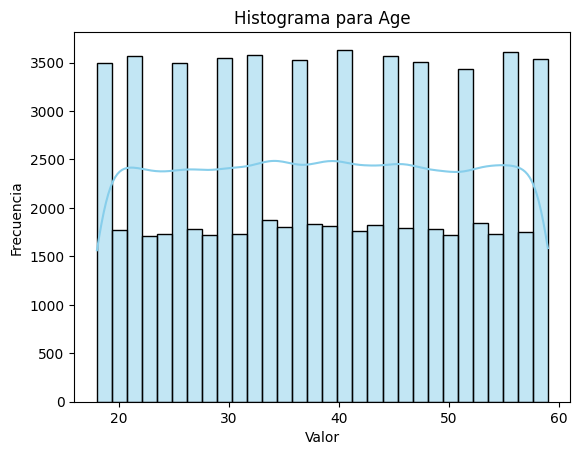

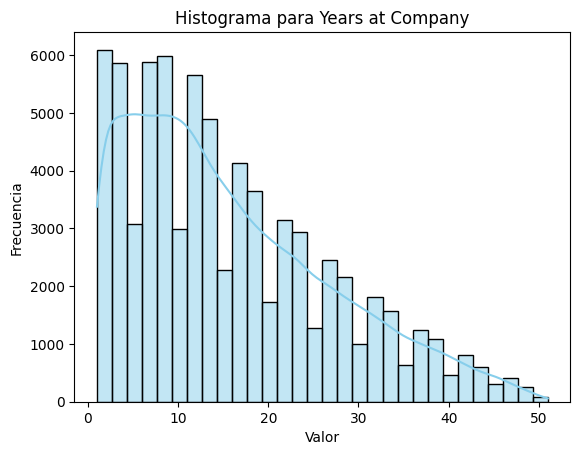

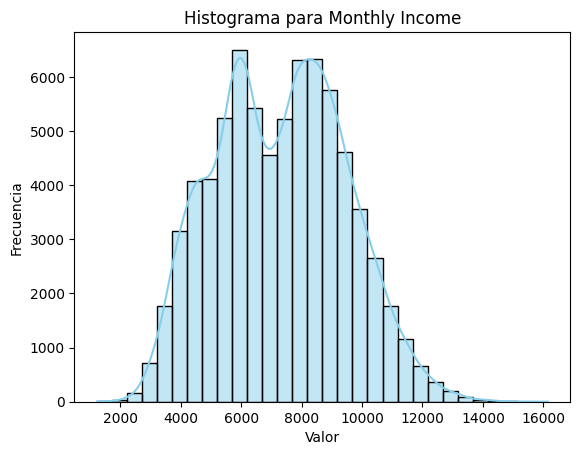

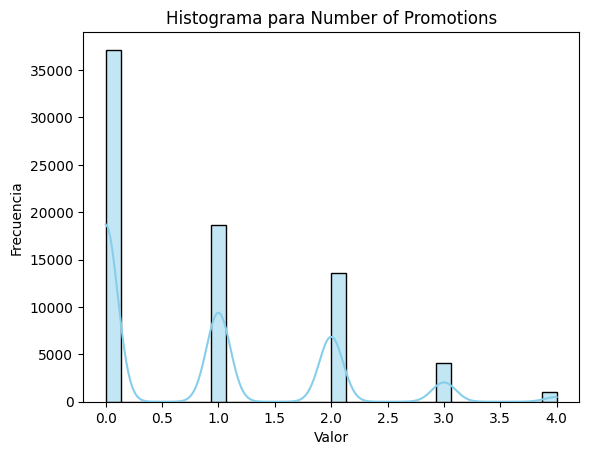

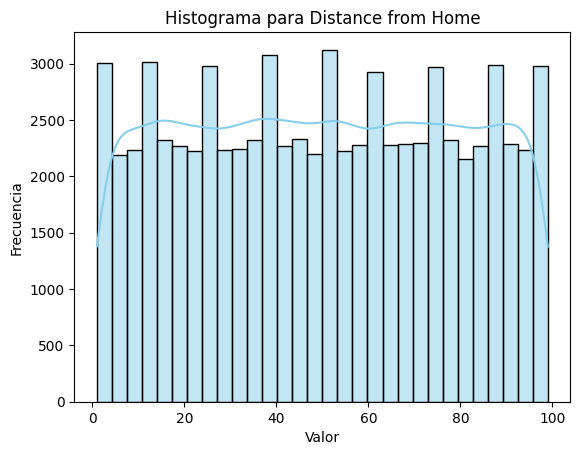

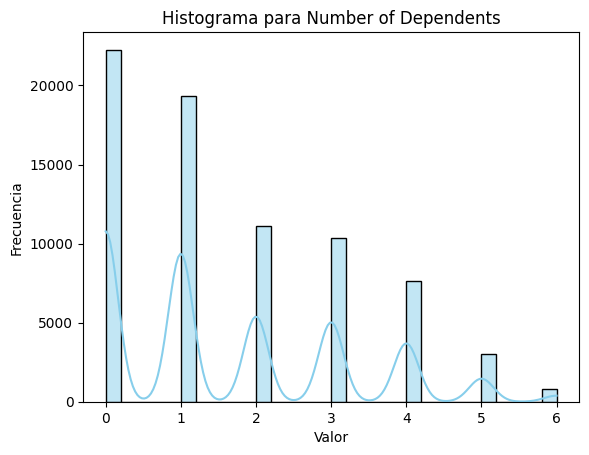

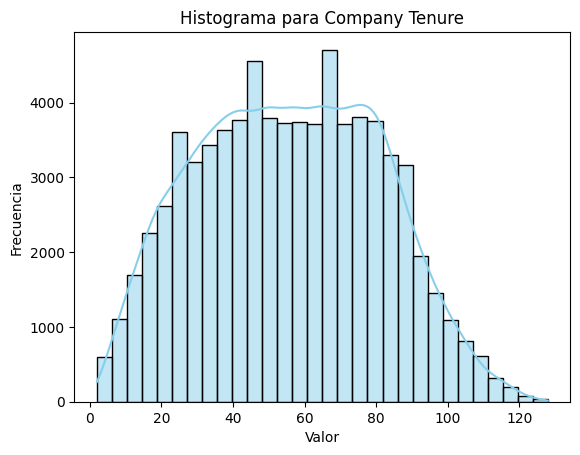

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración de los gráficos de densidad separados
for col in df[num_cols].columns:
    plt.figure()  # Crear una nueva figura para cada gráfico
    sns.histplot(df[col], bins=30, kde=True, color='skyblue')
    plt.title(f'Histograma para {col}')
    plt.xlabel('Valor')
    plt.ylabel('Frecuencia')
    plt.show()

# Nota: La línea que acompaña al histograma es la estimación de densidad kernel (KDE). El KDE es una forma de suavizar la distribución de los datos para obtener una función continua que estima la distribución de probabilidad subyacente. La línea KDE muestra cómo se distribuirían los datos si se modelaran como una distribución continua en lugar de un conjunto discreto de observaciones.

**insights:**

*   El histograma muestra que la distribución de edades en la empresa es bastante uniforme, con empleados en un rango amplio de 20 a 60 años. No hay una gran concentración en un solo grupo de edad, lo que sugiere una plantilla equilibrada en términos de experiencia y juventud.
*   Podemos decir que a medida que los años aumentan, la frecuencia disminuye progresivamente, por lo que es más común encontrar empleados con poca antigüedad que aquellos con muchos años en la empresa.
Alta rotación en los primeros años: Puede ser que muchos empleados dejen la empresa en los primeros 10 años.
* Para el numero de promovidos podemos decir que la gran mayoria de empleados no son promovidos, por lo que puede ser una posible fuga de talento mas adelante, mientras que los empleados con promovidos son muy pocos.






##### **Variables Categóricas**

In [ ]:
# Generando listas de variables categóricas
cat_cols = list(df.select_dtypes(include='object').columns)
cat_cols.remove('Employee ID')
print(f'columnas categoricas: {cat_cols}')

columnas categoricas: ['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Overtime', 'Education Level', 'Marital Status', 'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']


In [ ]:
def resumen_categorias(dataframe):
    for col in dataframe.select_dtypes(include='object').columns:
        total_categorias = len(dataframe[col].unique())
        print(f"Columna: {col}, Total de Categorías: {total_categorias}")

        top_10 = dataframe[col].value_counts().nlargest(10)
        porcentaje_top_10 = dataframe[col].value_counts(normalize=True).nlargest(10)* 100

        tabla_resumen = pd.DataFrame({
            'Categoría': top_10.index,
            'Cantidad': top_10.values,
            'Porcentaje': porcentaje_top_10.values
        })

        print(tabla_resumen)
        print("\n")

resumen_categorias(df[cat_cols])

Columna: Gender, Total de Categorías: 2
  Categoría  Cantidad  Porcentaje
0      Male     40826   54.801471
1    Female     33672   45.198529


Columna: Job Role, Total de Categorías: 5
    Categoría  Cantidad  Porcentaje
0  Technology     19322   25.936267
1  Healthcare     17074   22.918736
2   Education     15658   21.018014
3       Media     11996   16.102446
4     Finance     10448   14.024538


Columna: Work-Life Balance, Total de Categorías: 4
   Categoría  Cantidad  Porcentaje
0       Good     28158   37.796988
1       Fair     22529   30.241080
2  Excellent     13432   18.030014
3       Poor     10379   13.931918


Columna: Job Satisfaction, Total de Categorías: 4
   Categoría  Cantidad  Porcentaje
0       High     37245   49.994631
1  Very High     15079   20.240812
2     Medium     14717   19.754893
3        Low      7457   10.009665


Columna: Performance Rating, Total de Categorías: 4
       Categoría  Cantidad  Porcentaje
0        Average     44719   60.027115
1          

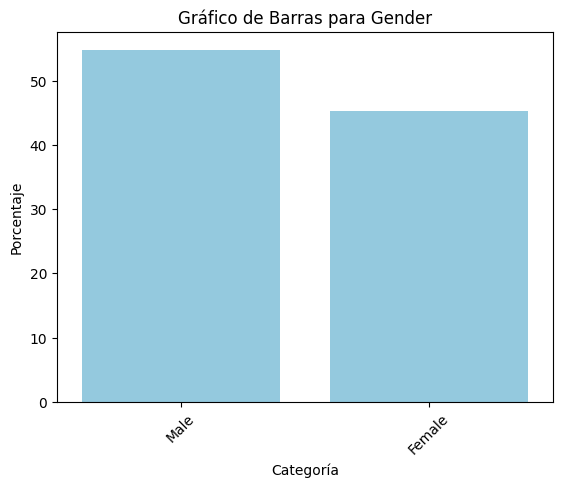

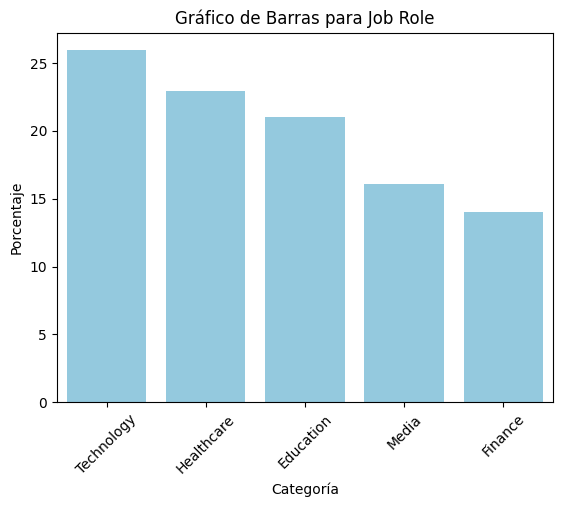

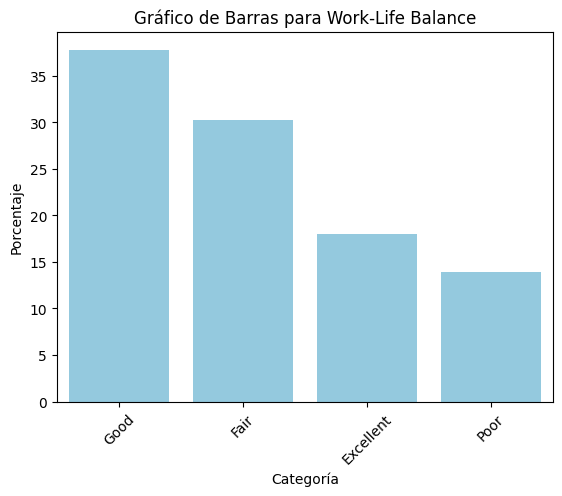

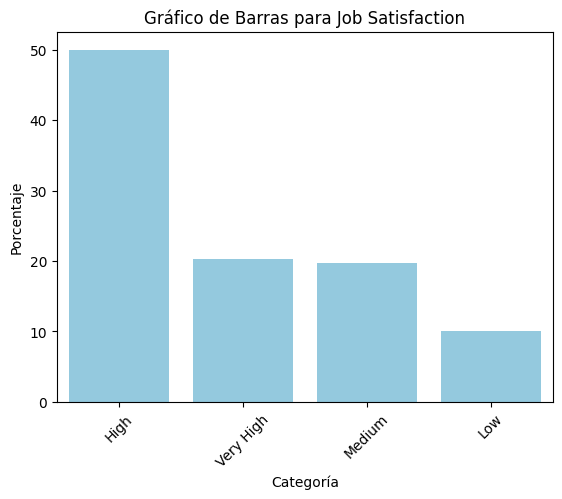

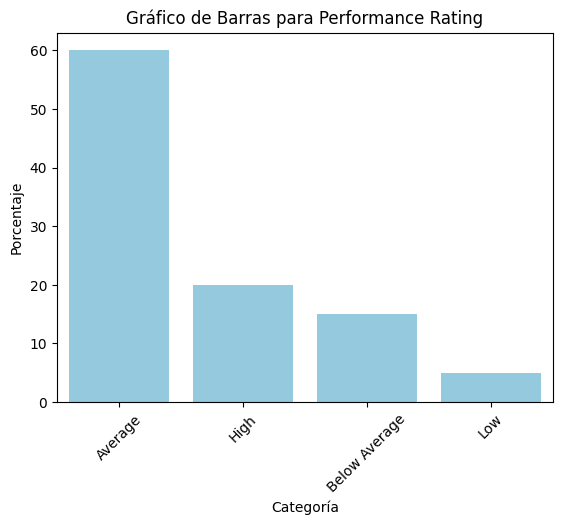

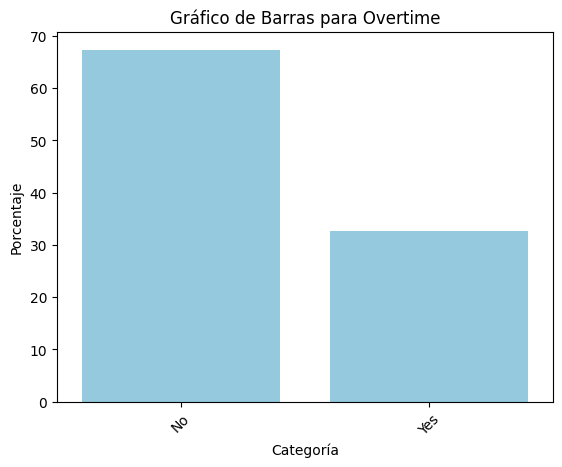

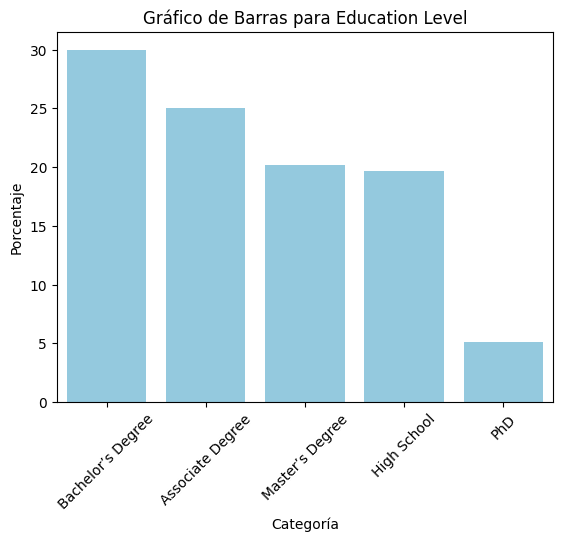

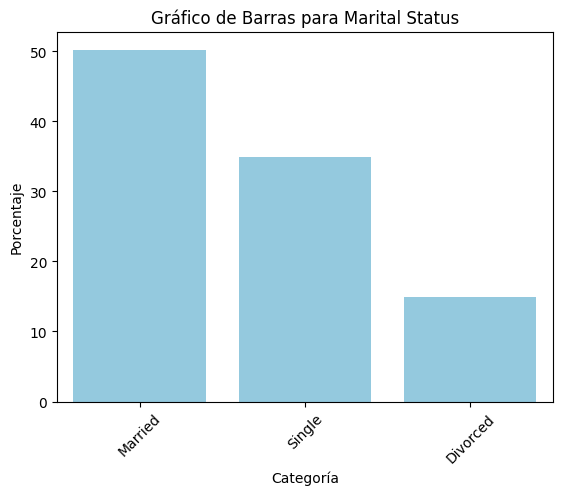

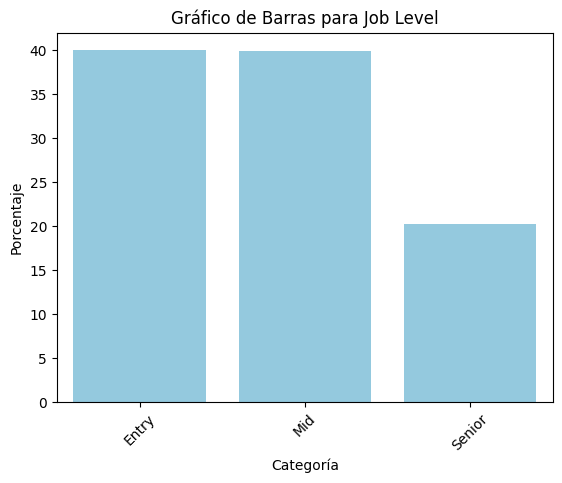

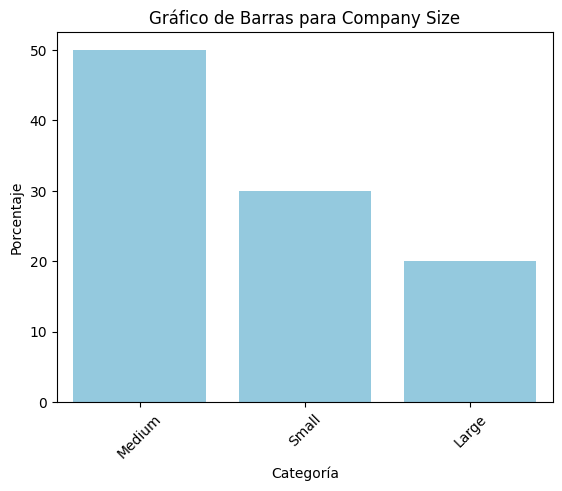

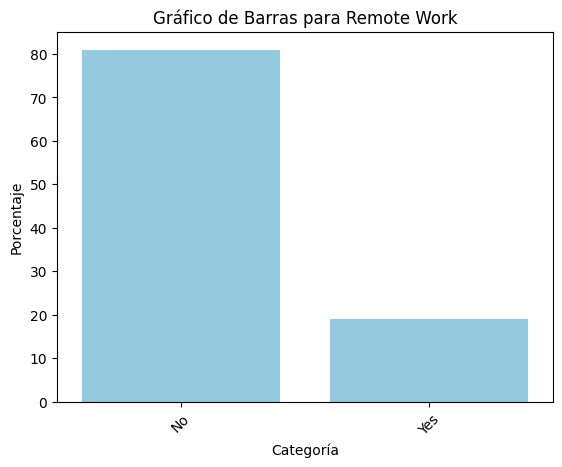

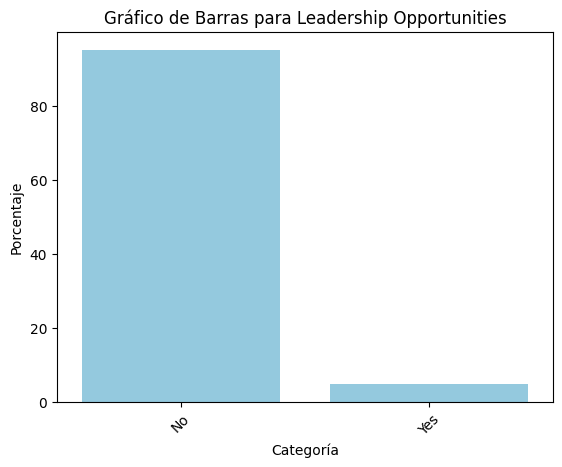

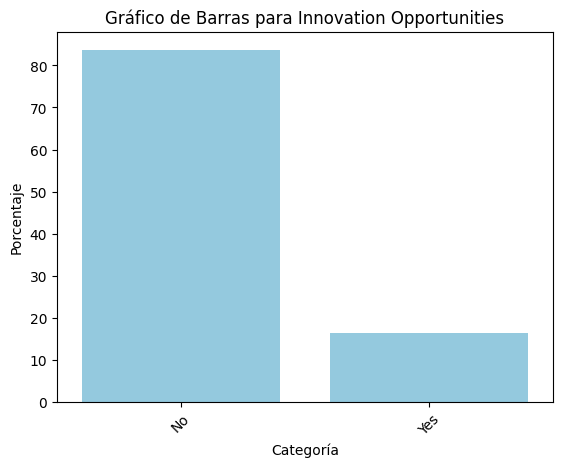

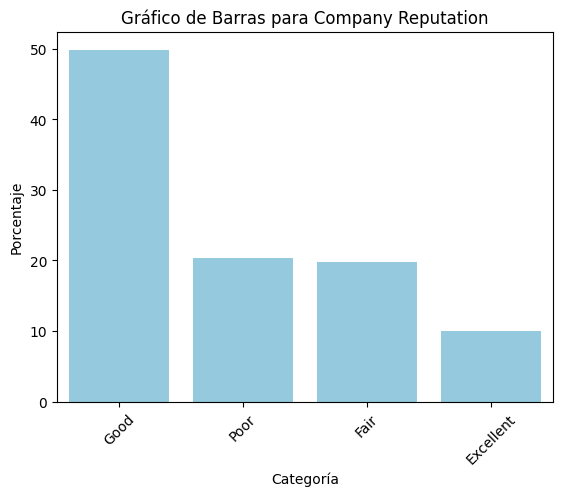

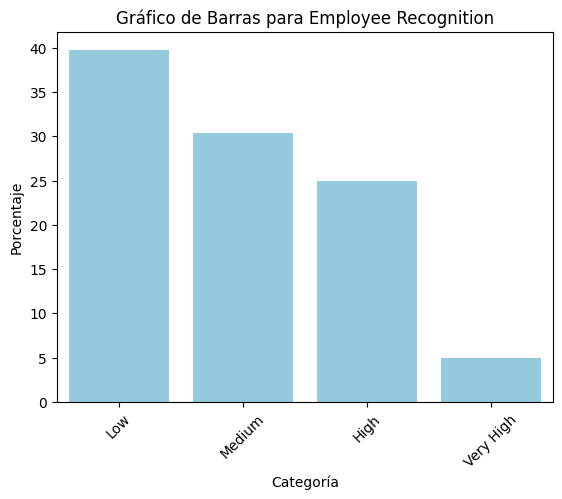

In [ ]:
# Obtener el porcentaje de cada categoría para cada columna categórica
for col in cat_cols:
    plt.figure()  # Crear una nueva figura para cada gráfico
    top_categories = df[col].value_counts().nlargest(10).index
    df_top10 = df[df[col].isin(top_categories)][col]
    sns.barplot(x= df_top10.value_counts(normalize=True).index,
            y=df_top10.value_counts(normalize=True) * 100, color='skyblue')
    plt.title(f'Gráfico de Barras para {col}')
    plt.xlabel('Categoría')
    plt.ylabel('Porcentaje')
    plt.xticks(rotation=45)  # Rotar los nombres de categorías
    plt.show()

**insights:**

*   Grafico de barras Gender: El gráfico de barras muestra la distribución porcentual de la variable "Gender". Se observa que hay una ligera mayoría de empleados de género masculino en comparación con el género femenino. La diferencia no parece ser extremadamente significativa, pero sí sugiere una composición de género desigual dentro de la empresa.



## **4. PREPARACION DE LOS DATOS** <a name="eda"></a>

###**a) Análisis de valores nulos y atípicos:**

####**Analizando valores nulos**

In [ ]:
df.info() #Se observa que No hay presencia de valores nulos

<class 'pandas.core.frame.DataFrame'>
Index: 74498 entries, 0 to 14899
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               74498 non-null  object
 1   Age                       74498 non-null  int64 
 2   Gender                    74498 non-null  object
 3   Years at Company          74498 non-null  int64 
 4   Job Role                  74498 non-null  object
 5   Monthly Income            74498 non-null  int64 
 6   Work-Life Balance         74498 non-null  object
 7   Job Satisfaction          74498 non-null  object
 8   Performance Rating        74498 non-null  object
 9   Number of Promotions      74498 non-null  int64 
 10  Overtime                  74498 non-null  object
 11  Distance from Home        74498 non-null  int64 
 12  Education Level           74498 non-null  object
 13  Marital Status            74498 non-null  object
 14  Number of Dependents      7

In [ ]:
# Crear una función que nos ayude a determinar el % de nulos por columna

def porcentaje_nulos(dataframe):
    # Calcula el total de valores nulos por columna
    nulos_por_columna = dataframe.isnull().sum()

    # Calcula el porcentaje de valores nulos por columna
    porcentaje_nulos = (nulos_por_columna / len(dataframe)) * 100

    # Combina los resultados en un nuevo dataframe
    resumen_nulos = pd.DataFrame({
        'Columna': nulos_por_columna.index,
        'Valores Nulos': nulos_por_columna.values,
        '% Nulos': porcentaje_nulos.values
    })

    return resumen_nulos

In [ ]:
resumen_nulos = porcentaje_nulos(df)
resumen_nulos

,Columna,Valores Nulos,% Nulos
0,Employee ID,0,0.0
1,Age,0,0.0
2,Gender,0,0.0
3,Years at Company,0,0.0
4,Job Role,0,0.0
5,Monthly Income,0,0.0
6,Work-Life Balance,0,0.0
7,Job Satisfaction,0,0.0
8,Performance Rating,0,0.0
9,Number of Promotions,0,0.0


**Conclusión:** El conjunto de datos no contiene valores Nulos

####**Analizando outliers**

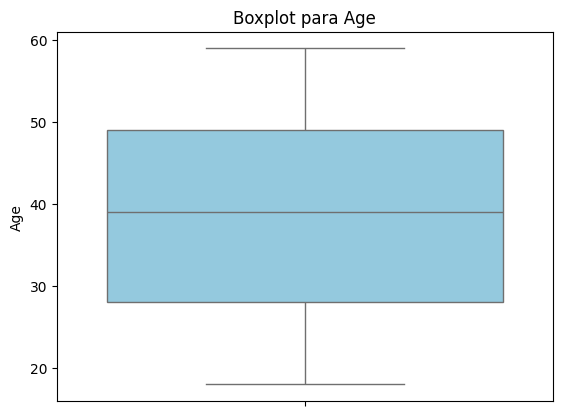

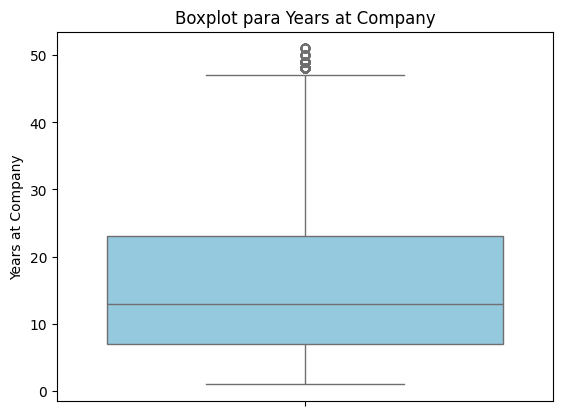

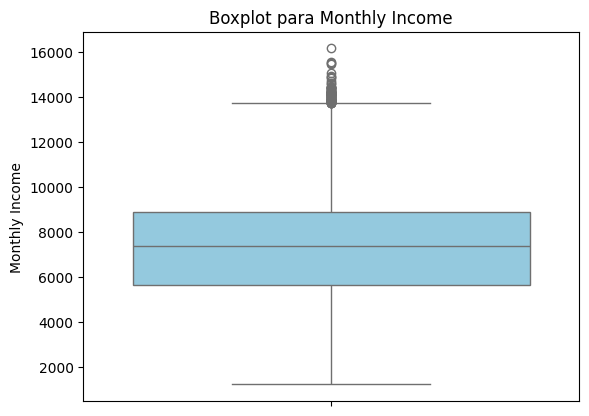

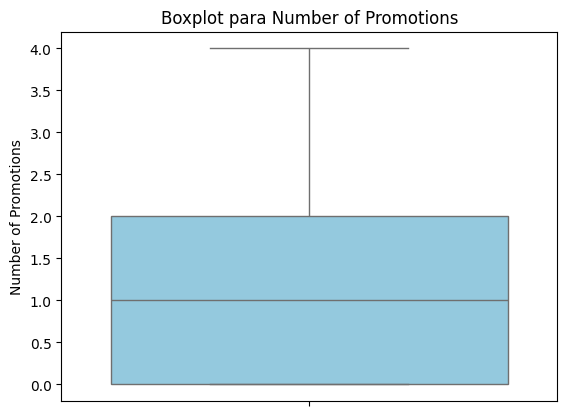

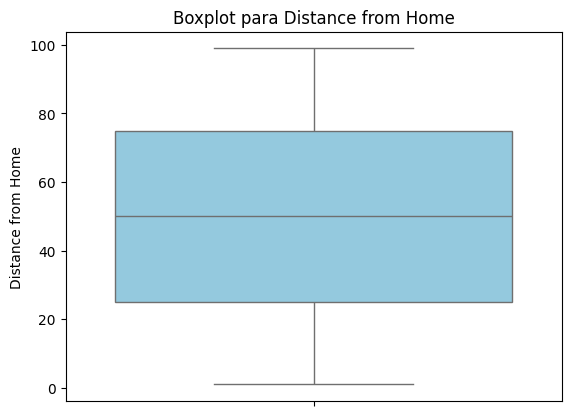

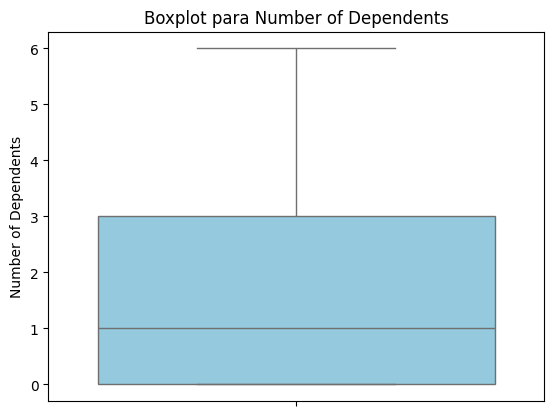

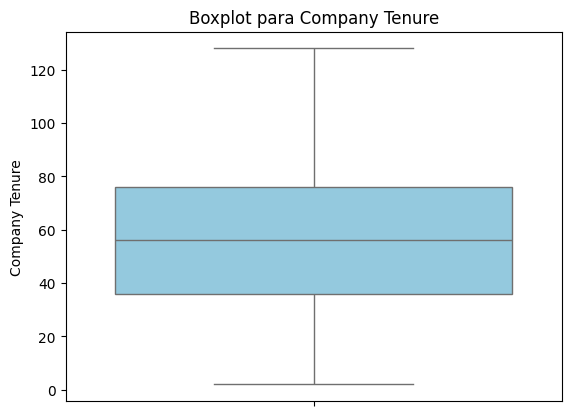

In [ ]:
# Crear un boxplot para cada variable
for col in df[num_cols].columns:
    plt.figure()  # Crear una nueva figura para cada boxplot
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot para {col}')
    plt.show()

**Conclusión:** Se detectaron valores atípicos en las columnas de Monthly Income y Years at Company

In [ ]:
# Cantidad y porcentaje de valores atipicos de Years at Company

# Calcular el número y porcentaje de outliers en 'Years at Company'
Q1 = df['Years at Company'].quantile(0.25)
Q3 = df['Years at Company'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Years at Company'] < lower_bound) | (df['Years at Company'] > upper_bound)]
num_outliers = len(outliers)
percentage_outliers = (num_outliers / len(df)) * 100

print(f"Number of outliers in 'Years at Company': {num_outliers}")
print(f"Percentage of outliers in 'Years at Company': {percentage_outliers:.2f}%")


Number of outliers in 'Years at Company': 338
Percentage of outliers in 'Years at Company': 0.45%


In [ ]:
# Cantidad y porcentaje de valores atipicos de Monthly Income

# Calcular el número y porcentaje de outliers en 'Monthly Income'
Q1 = df['Monthly Income'].quantile(0.25)
Q3 = df['Monthly Income'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Monthly Income'] < lower_bound) | (df['Monthly Income'] > upper_bound)]
num_outliers = len(outliers)
percentage_outliers = (num_outliers / len(df)) * 100

print(f"Number of outliers in 'Years at Company': {num_outliers}")
print(f"Percentage of outliers in 'Years at Company': {percentage_outliers:.2f}%")

Number of outliers in 'Years at Company': 65
Percentage of outliers in 'Years at Company': 0.09%


In [ ]:
# Eliminar los valores atipicos de Monthly Income y Years at Company

# Definir la función para eliminar outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_filtered

# Eliminar outliers de 'Monthly Income'
df = remove_outliers(df, 'Monthly Income')

# Eliminar outliers de 'Years at Company'
df = remove_outliers(df, 'Years at Company')


print(f"Datos después de eliminar valores atípicos: {len(df)}")

Datos después de eliminar valores atípicos: 74095


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74095 entries, 0 to 14898
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               74095 non-null  object
 1   Age                       74095 non-null  int64 
 2   Gender                    74095 non-null  object
 3   Years at Company          74095 non-null  int64 
 4   Job Role                  74095 non-null  object
 5   Monthly Income            74095 non-null  int64 
 6   Work-Life Balance         74095 non-null  object
 7   Job Satisfaction          74095 non-null  object
 8   Performance Rating        74095 non-null  object
 9   Number of Promotions      74095 non-null  int64 
 10  Overtime                  74095 non-null  object
 11  Distance from Home        74095 non-null  int64 
 12  Education Level           74095 non-null  object
 13  Marital Status            74095 non-null  object
 14  Number of Dependents      7

In [ ]:
df.describe()

,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure,target
count,74095.000000,74095.000000,74095.000000,74095.000000,74095.000000,74095.000000,74095.000000,74095.000000
mean,38.441609,15.570794,7293.588920,0.833039,50.001943,1.650611,55.572022,0.524921
std,12.039396,11.022483,2143.717864,0.995316,28.519787,1.553784,25.312777,0.499382
min,18.000000,1.000000,1226.000000,0.000000,1.000000,0.000000,2.000000,0.000000
25%,28.000000,7.000000,5651.000000,0.000000,25.000000,0.000000,36.000000,0.000000
50%,38.000000,13.000000,7346.000000,1.000000,50.000000,1.000000,56.000000,1.000000
75%,49.000000,23.000000,8871.000000,2.000000,75.000000,3.000000,75.000000,1.000000
max,59.000000,47.000000,13705.000000,4.000000,99.000000,6.000000,126.000000,1.000000


###**b) Transformación de variables categóricas a numéricas:**

####**Transformando categoricas a numéricas**

In [ ]:
binary_cols = ['Remote Work', 'Overtime', 'Leadership Opportunities', 'Innovation Opportunities'] ## columnas binarias

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0}) ## cambia los yes / no por valores 1 y 0

In [ ]:
mappings = {
    'Education Level': {  #  Nivel educativo
        'High School': 0,
        'Associate Degree': 1,
        "Bachelor’s Degree": 2,
        "Master’s Degree": 3,
        'PhD': 4
    },
    'Job Role': {  #  -- aquí está -- Rol del trabajo
        'Education': 0,
        'Finance': 1,
        'Healthcare': 2,
        'Media': 3,
        'Technology': 4
    },
    'Job Level': {  #  Nivel del trabajo
        'Entry': 0,
        'Mid': 1,
        'Senior': 2
    },
    'Company Size': {  #  Tamaño de la empresa
        'Small': 0,
        'Medium': 1,
        'Large': 2
    },
    'Company Reputation': {  # Reputación de la empresa
        'Poor': 0,
        'Fair': 1,
        'Good': 2,
        'Excellent': 3
    },
    'Employee Recognition': {  #  Reconocimiento del empleado
        'Low': 0,
        'Medium': 1,
        'High': 2,
        'Very High': 3
    },
    'Performance Rating': {  #  Calificación de desempeño
        'Low': 0,
        'Below Average': 1,
        'Average': 2,
        'High': 3
    },
    'Job Satisfaction': {  #  Satisfacción en el trabajo
        'Low': 0,
        'Medium': 1,
        'High': 2,
        'Very High': 3
    },
    'Work-Life Balance': {  #  -- aquí está -- Equilibrio trabajo-vida
        'Poor': 0,
        'Fair': 1,
        'Good': 2,
        'Excellent': 3
    },
    'Marital Status': {  #  -- aquí está -- Estado civil
        'Divorced': 0,
        'Married': 1,
        'Single': 2
    },
    'Gender': {  #  -- aquí está -- Género
        'Male': 0,
        'Female': 1
    }
}

# Aplicar la transformación en todas las columnas definidas en mappings
for col, mapping in mappings.items():
    df[col] = df[col].map(mapping)

In [ ]:
df.head(20)

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,target
0,0008410,31,0,19,0,5390,3,1,2,2,...,0,1,1,89,0,0,0,3,1,1
1,0064756,59,1,4,3,5534,0,2,0,3,...,3,1,1,21,0,0,0,1,0,1
2,0030257,24,1,10,2,8159,2,2,0,0,...,3,1,1,74,0,0,0,0,0,1
3,0065791,36,1,7,0,3989,2,2,3,1,...,2,1,0,50,1,0,0,2,1,1
4,0065026,56,0,41,0,4821,1,3,2,0,...,0,2,1,68,0,0,0,1,1,1
5,0024368,38,1,3,4,9977,1,2,1,3,...,0,1,1,47,0,0,1,1,2,0
6,0064970,47,0,23,0,3681,1,2,3,1,...,3,0,0,93,0,0,0,2,1,0
7,0036999,48,0,16,1,11223,3,3,3,2,...,4,0,1,88,0,0,0,3,0,1
8,0032714,57,0,44,0,3773,2,1,3,1,...,4,0,1,75,0,0,0,1,1,1
9,0015944,24,1,1,2,7319,0,2,2,1,...,4,0,2,45,0,0,1,2,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74095 entries, 0 to 14898
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               74095 non-null  object
 1   Age                       74095 non-null  int64 
 2   Gender                    74095 non-null  int64 
 3   Years at Company          74095 non-null  int64 
 4   Job Role                  74095 non-null  int64 
 5   Monthly Income            74095 non-null  int64 
 6   Work-Life Balance         74095 non-null  int64 
 7   Job Satisfaction          74095 non-null  int64 
 8   Performance Rating        74095 non-null  int64 
 9   Number of Promotions      74095 non-null  int64 
 10  Overtime                  74095 non-null  int64 
 11  Distance from Home        74095 non-null  int64 
 12  Education Level           74095 non-null  int64 
 13  Marital Status            74095 non-null  int64 
 14  Number of Dependents      7

###**C) Ingeniería de variables:**

####**seleccionando las variables potenciales**

In [ ]:
df = df.drop(columns=["Employee ID","Company Tenure"]) ## elimnar tenure


In [ ]:
vars_predict = list(df.columns)
vars_predict.remove('target')
vars_predict

['Age',
 'Gender',
 'Years at Company',
 'Job Role',
 'Monthly Income',
 'Work-Life Balance',
 'Job Satisfaction',
 'Performance Rating',
 'Number of Promotions',
 'Overtime',
 'Distance from Home',
 'Education Level',
 'Marital Status',
 'Number of Dependents',
 'Job Level',
 'Company Size',
 'Remote Work',
 'Leadership Opportunities',
 'Innovation Opportunities',
 'Company Reputation',
 'Employee Recognition']

In [ ]:
df_final = df.copy()

## **5. MODELADO** <a name="modelado"></a>

###**Algoritmos:**

####**Árbol de decision**

* El AUC-ROC varía de 0 a 1.
* AUC-ROC cercano a 1: Indica un modelo con un buen rendimiento en la clasificación. Cuanto más cercano a 1, mejor.
* AUC-ROC cercano a 0.5: Indica que el modelo tiene un rendimiento similar al azar.
* AUC-ROC cercano a 0: Indica un modelo con un rendimiento pobre y probablemente invierte las clases.



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score
from scipy.stats import randint
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

# X son tus variables predictoras y y es tu variable objetivo
X = df_final[vars_predict]  # Reemplaza con tus variables predictoras
y = df_final['target']  # Reemplaza con tu variable objetivo

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Inicializar el objeto RandomOverSampler
oversampler = RandomOverSampler(random_state=42)

# Aplicar oversampling solo al conjunto de entrenamiento
X_train_resampled, y_train_resampled = oversampler.fit_resample(X_train, y_train)

# Verificar el nuevo balance de clases
print("Distribución de clases después del oversampling:")
print(pd.Series(y_train_resampled).value_counts())

# Definir los espacios de búsqueda de hiperparámetros para el árbol de decisión
param_dist_decision_tree = {
    'max_depth': randint(3, 10),           # Profundidad máxima del árbol
    'min_samples_split': randint(2, 20),    # Mínimo de muestras para dividir un nodo
    'min_samples_leaf': randint(1, 20),     # Mínimo de muestras en una hoja
}

# Inicializar el modelo de árbol de decisión
modelo_decision_tree = DecisionTreeClassifier(random_state=42)

# Realizar la búsqueda aleatoria para el árbol de decisión en el conjunto de entrenamiento oversampleado
random_search_decision_tree = RandomizedSearchCV(modelo_decision_tree, param_distributions=param_dist_decision_tree, n_iter=2, cv=3, scoring='roc_auc', random_state=42)
random_search_decision_tree.fit(X_train_resampled, y_train_resampled)

# Obtener el mejor modelo de árbol de decisión
mejor_modelo_decision_tree = random_search_decision_tree.best_estimator_

# Predecir probabilidades en el conjunto de prueba
y_prob_decision_tree = mejor_modelo_decision_tree.predict_proba(X_test)[:, 1]

# Evaluar el rendimiento del modelo de árbol de decisión en el conjunto de prueba original usando AUC
auc_decision_tree = roc_auc_score(y_test, y_prob_decision_tree)
print(f'AUC Árbol de Decisión con Optimización y Oversampling: {auc_decision_tree:.4f}')

# Predecir en el conjunto de prueba
y_pred_decision_tree = mejor_modelo_decision_tree.predict(X_test)

# Calcular y mostrar la matriz de confusión
conf_matrix_decision_tree = confusion_matrix(y_test, y_pred_decision_tree)
print("Matriz de Confusión:")
print(conf_matrix_decision_tree)

# Calcular y mostrar la precisión (accuracy)
accuracy_decision_tree = accuracy_score(y_test, y_pred_decision_tree)
print(f'Precisión Árbol de Decisión con Optimización y Oversampling: {accuracy_decision_tree:.4f}')

# Imprimir los mejores hiperparámetros encontrados
print("Mejores hiperparámetros Árbol de Decisión:", random_search_decision_tree.best_params_)

Distribución de clases después del oversampling:
target
0    31115
1    31115
Name: count, dtype: int64
AUC Árbol de Decisión con Optimización y Oversampling: 0.8197
Matriz de Confusión:
[[5378 1662]
 [2311 5468]]
Precisión Árbol de Decisión con Optimización y Oversampling: 0.7319
Mejores hiperparámetros Árbol de Decisión: {'max_depth': 9, 'min_samples_leaf': 15, 'min_samples_split': 12}


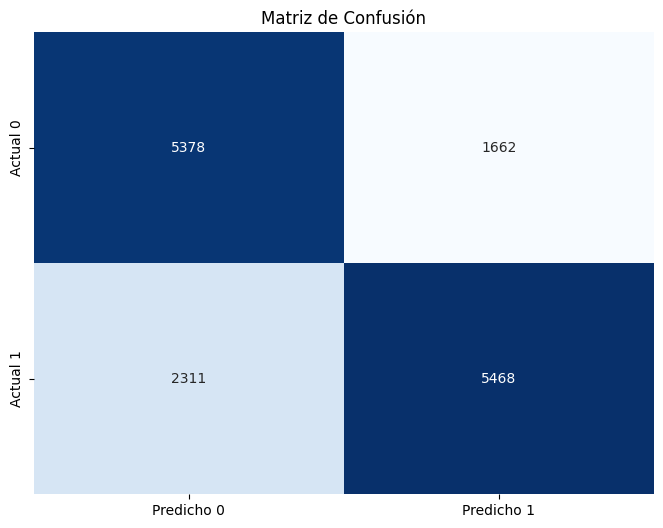

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un DataFrame para visualizar la matriz de confusión
confusion_df = pd.DataFrame(conf_matrix_decision_tree, index=['Actual 0', 'Actual 1'], columns=['Predicho 0', 'Predicho 1'])

# Visualizar la matriz de confusión como una tabla
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión')
plt.show()

El modelo tiene una precisión de 75.40% y un AUC de 0.8483
por lo que podemos decir el modelo acierta las predicciones.
* Precisión Calculada:
(VP + VN) / Total = (5405 + 5768) / 14819 = 0.7540
* AUC > 0.8:
Buen desempeño (el valor 0.84 es considerado alto).


####**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

# X son tus variables predictoras y y es tu variable objetivo
X = df_final[vars_predict]  # Reemplaza con tus variables predictoras
y = df_final['target']  # Reemplaza con tu variable objetivo

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Inicializar el objeto RandomOverSampler
oversampler = RandomOverSampler(random_state=42)

# Aplicar oversampling solo al conjunto de entrenamiento
X_train_resampled, y_train_resampled = oversampler.fit_resample(X_train, y_train)

# Verificar el nuevo balance de clases
print("Distribución de clases después del oversampling:")
print(pd.Series(y_train_resampled).value_counts())

# Definir los espacios de búsqueda de hiperparámetros para Random Forest
param_dist_random_forest = {
    'n_estimators': randint(50, 200),          # Número de árboles en el bosque
    'max_depth': randint(3, 10),               # Profundidad máxima de cada árbol
    'min_samples_split': randint(2, 20),       # Mínimo de muestras para dividir un nodo
    'min_samples_leaf': randint(1, 20),        # Mínimo de muestras en una hoja
}

# Inicializar el modelo de Random Forest
modelo_random_forest = RandomForestClassifier(random_state=42)

# Realizar la búsqueda aleatoria para Random Forest en el conjunto de entrenamiento oversampleado
random_search_random_forest = RandomizedSearchCV(modelo_random_forest, param_distributions=param_dist_random_forest, n_iter=2, cv=3, scoring='roc_auc', random_state=42)
random_search_random_forest.fit(X_train_resampled, y_train_resampled)

# Obtener el mejor modelo de Random Forest
mejor_modelo_random_forest = random_search_random_forest.best_estimator_

# Predecir probabilidades en el conjunto de prueba
y_prob_random_forest = mejor_modelo_random_forest.predict_proba(X_test)[:, 1]

# Evaluar el rendimiento del modelo de Random Forest en el conjunto de prueba original usando AUC
auc_random_forest = roc_auc_score(y_test, y_prob_random_forest)
print(f'AUC Random Forest con Optimización y Oversampling: {auc_random_forest:.4f}')

# Predecir en el conjunto de prueba
y_pred_random_forest = mejor_modelo_random_forest.predict(X_test)

# Calcular y mostrar la matriz de confusión
conf_matrix_random_forest = confusion_matrix(y_test, y_pred_random_forest)
print("Matriz de Confusión para Random Forest:")
print(conf_matrix_random_forest)

# Calcular y mostrar la precisión (accuracy)
accuracy_random_forest = accuracy_score(y_test, y_pred_random_forest)
print(f'Precisión Random Forest con Optimización y Oversampling: {accuracy_random_forest:.4f}')

# Imprimir los mejores hiperparámetros encontrados
print("Mejores hiperparámetros Random Forest:", random_search_random_forest.best_params_)



Distribución de clases después del oversampling:
target
0    31115
1    31115
Name: count, dtype: int64
AUC Random Forest con Optimización y Oversampling: 0.8395
Matriz de Confusión para Random Forest:
[[5354 1686]
 [2055 5724]]
Precisión Random Forest con Optimización y Oversampling: 0.7476
Mejores hiperparámetros Random Forest: {'max_depth': 9, 'min_samples_leaf': 15, 'min_samples_split': 12, 'n_estimators': 121}


####**XGBoost**

In [ ]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

# X son tus variables predictoras y y es tu variable objetivo
X = df_final[vars_predict]  # Reemplaza con tus variables predictoras
y = df_final['target']  # Reemplaza con tu variable objetivo

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Inicializar el objeto RandomOverSampler
oversampler = RandomOverSampler(random_state=42)

# Aplicar oversampling solo al conjunto de entrenamiento
X_train_resampled, y_train_resampled = oversampler.fit_resample(X_train, y_train)

# Verificar el nuevo balance de clases
print("Distribución de clases después del oversampling:")
print(pd.Series(y_train_resampled).value_counts())

# Definir los espacios de búsqueda de hiperparámetros para XGBoost
param_dist_xgboost = {
    'n_estimators': randint(50, 200),      # Número de árboles
    'max_depth': randint(3, 10),           # Profundidad máxima de cada árbol
    'learning_rate': [0.01, 0.1, 0.2],    # Tasa de aprendizaje
    'subsample': [0.8, 0.9, 1.0],         # Proporción de muestras utilizadas para entrenar cada árbol
    'min_child_weight': randint(1, 10),    # Peso mínimo de las muestras en cada hoja
}

# Inicializar el modelo de XGBoost
modelo_xgboost = xgb.XGBClassifier(random_state=42)

# Realizar la búsqueda aleatoria para XGBoost en el conjunto de entrenamiento oversampleado
random_search_xgboost = RandomizedSearchCV(modelo_xgboost, param_distributions=param_dist_xgboost, n_iter=2, cv=3, scoring='roc_auc', random_state=42)
random_search_xgboost.fit(X_train_resampled, y_train_resampled)

# Obtener el mejor modelo de XGBoost
mejor_modelo_xgboost = random_search_xgboost.best_estimator_

# Predecir probabilidades en el conjunto de prueba
y_prob_xgboost = mejor_modelo_xgboost.predict_proba(X_test)[:, 1]

# Evaluar el rendimiento del modelo de XGBoost en el conjunto de prueba original usando AUC
auc_xgboost = roc_auc_score(y_test, y_prob_xgboost)
print(f'AUC XGBoost con Optimización y Oversampling: {auc_xgboost:.4f}')

# Predecir en el conjunto de prueba
y_pred_xgboost = mejor_modelo_xgboost.predict(X_test)

# Calcular y mostrar la matriz de confusión
conf_matrix_xgboost = confusion_matrix(y_test, y_pred_xgboost)
print("Matriz de Confusión para XGBoost:")
print(conf_matrix_xgboost)

# Calcular y mostrar la precisión (accuracy)
accuracy_xgboost = accuracy_score(y_test, y_pred_xgboost)
print(f'Precisión XGBoost con Optimización y Oversampling: {accuracy_xgboost:.4f}')

# Imprimir los mejores hiperparámetros encontrados
print("Mejores hiperparámetros XGBoost:", random_search_xgboost.best_params_)


Distribución de clases después del oversampling:
target
0    31115
1    31115
Name: count, dtype: int64
AUC XGBoost con Optimización y Oversampling: 0.8483
Matriz de Confusión para XGBoost:
[[5405 1635]
 [2011 5768]]
Precisión XGBoost con Optimización y Oversampling: 0.7540
Mejores hiperparámetros XGBoost: {'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 7, 'n_estimators': 124, 'subsample': 1.0}


###**Comparación de Algoritmos**

**Conclusión:**

*   AUC Árbol de Decisión con Optimización y Oversampling: 0.8197
*   AUC Random Forest con Optimización y Oversampling: 0.8395
*   AUC XGBoost con Optimización y Oversampling: 0.8483

**Entonces gana el modelo de XGBoost**





###**Analizando variables más importantes**

In [ ]:
# Obtener importancias de características y árboles individuales
importancias_variables_xg = mejor_modelo_xgboost.feature_importances_

# Obtener nombres de columnas
nombres_variables = X_train.columns

# Crear un DataFrame con las importancias y gain
df_importancias = pd.DataFrame({'Variable': nombres_variables, 'Importancia': importancias_variables_xg})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

# Calcular el porcentaje acumulado de importancia
df_importancias['Porcentaje Acumulado'] = df_importancias['Importancia'].cumsum() * 100


df_importancias

,Variable,Importancia,Porcentaje Acumulado
14,Job Level,0.193104,19.310410
12,Marital Status,0.145858,33.896221
16,Remote Work,0.127915,46.687752
5,Work-Life Balance,0.078187,54.506462
1,Gender,0.059055,60.411922
11,Education Level,0.052728,65.684769
8,Number of Promotions,0.051804,70.865135
13,Number of Dependents,0.047703,75.635422
19,Company Reputation,0.047158,80.351196
9,Overtime,0.035731,83.924278


###**Analizando correlación de variables**

In [ ]:
import pandas as pd
import numpy as np

def eliminar_variables_correlacionadas(df, umbral_correlacion=0.7, seed=None):
    """
    Analiza la correlación entre variables en un DataFrame.
    Elimina una de las variables en cada par correlacionado y devuelve la lista final de variables.

    Parameters:
    - df (pd.DataFrame): DataFrame con las variables.
    - umbral_correlacion (float): Umbral de correlación para considerar variables correlacionadas.
    - seed (int): Semilla para reproducibilidad.

    Returns:
    - Lista final de variables sin correlación.
    """
    # Calcula la matriz de correlación
    matriz_correlacion = df.corr().abs()

    # Encuentra las variables correlacionadas
    variables_correlacionadas = []
    for i in range(len(matriz_correlacion.columns)):
        for j in range(i):
            if matriz_correlacion.iloc[i, j] > umbral_correlacion:
                variables_correlacionadas.append((matriz_correlacion.columns[i], matriz_correlacion.columns[j]))

    # Elimina una variable de cada par correlacionado
    variables_a_eliminar = set()
    np.random.seed(seed)
    for par in variables_correlacionadas:
        variable_a_eliminar = np.random.choice(par)
        variables_a_eliminar.add(variable_a_eliminar)

    # Crea la lista final de variables sin correlación
    variables_sin_correlacion = list(set(df.columns) - variables_a_eliminar)

    return variables_sin_correlacion, variables_correlacionadas

# Ejemplo de uso:
# df es tu DataFrame
variables_sin_correlacion,variables_correlacionadas = eliminar_variables_correlacionadas(df_final[vars_predict])
print("Cantidad de variables inicial:", len(vars_predict))
print("Cantidad de variables sin correlación:", len(variables_sin_correlacion))
print("variables correlacionadas:", variables_correlacionadas)
print("Variables sin correlación:", variables_sin_correlacion)


Cantidad de variables inicial: 21
Cantidad de variables sin correlación: 21
variables correlacionadas: []
Variables sin correlación: ['Employee Recognition', 'Company Reputation', 'Number of Dependents', 'Marital Status', 'Remote Work', 'Job Level', 'Leadership Opportunities', 'Work-Life Balance', 'Overtime', 'Years at Company', 'Company Size', 'Age', 'Job Role', 'Job Satisfaction', 'Monthly Income', 'Number of Promotions', 'Gender', 'Performance Rating', 'Innovation Opportunities', 'Education Level', 'Distance from Home']


###**Definición de variables finales para el modelo**

In [ ]:
# Seleccionando a las vars con 95% de la importancia total ---> PARETO
vars_95 = df_importancias[df_importancias['Porcentaje Acumulado']<=95.1]['Variable']
lista_vars_95 = list(vars_95)
print('cantidad de vars finales por importancia',len(lista_vars_95))
lista_vars_95

cantidad de vars finales por importancia 15


['Job Level',
 'Marital Status',
 'Remote Work',
 'Work-Life Balance',
 'Gender',
 'Education Level',
 'Number of Promotions',
 'Number of Dependents',
 'Company Reputation',
 'Overtime',
 'Distance from Home',
 'Job Satisfaction',
 'Performance Rating',
 'Years at Company',
 'Company Size']

In [ ]:
# Generando una lista final cruzando las vars seleccionadas por la importancia con las finalistas luego de la correlación
vars_finales = list(set(vars_95).intersection(variables_sin_correlacion))
print('cantidad de vars finales',len(vars_finales))
vars_finales

cantidad de vars finales 15


['Company Size',
 'Company Reputation',
 'Number of Dependents',
 'Remote Work',
 'Marital Status',
 'Job Level',
 'Job Satisfaction',
 'Number of Promotions',
 'Distance from Home',
 'Gender',
 'Performance Rating',
 'Work-Life Balance',
 'Overtime',
 'Education Level',
 'Years at Company']

###**Entrenamiento del modelo final**

In [ ]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

# X son tus variables predictoras y y es tu variable objetivo
X = df_final[vars_finales]  # Reemplaza con tus variables predictoras
y = df_final['target']  # Reemplaza con tu variable objetivo

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Inicializar el objeto RandomOverSampler
oversampler = RandomOverSampler(random_state=42)

# Aplicar oversampling solo al conjunto de entrenamiento
X_train_resampled, y_train_resampled = oversampler.fit_resample(X_train, y_train)

# Verificar el nuevo balance de clases
print("Distribución de clases después del oversampling:")
print(pd.Series(y_train_resampled).value_counts())

# Definir los espacios de búsqueda de hiperparámetros para XGBoost
param_dist_xgboost = {
    'n_estimators': randint(50, 200),      # Número de árboles
    'max_depth': randint(3, 10),           # Profundidad máxima de cada árbol
    'learning_rate': [0.01, 0.1, 0.2],    # Tasa de aprendizaje
    'subsample': [0.8, 0.9, 1.0],         # Proporción de muestras utilizadas para entrenar cada árbol
    'min_child_weight': randint(1, 10),    # Peso mínimo de las muestras en cada hoja
}

# Inicializar el modelo de XGBoost
modelo_xgboost = xgb.XGBClassifier(random_state=42)

# Realizar la búsqueda aleatoria para XGBoost en el conjunto de entrenamiento oversampleado
random_search_xgboost = RandomizedSearchCV(modelo_xgboost, param_distributions=param_dist_xgboost, n_iter=2, cv=3, scoring='roc_auc', random_state=42)
random_search_xgboost.fit(X_train_resampled, y_train_resampled)

# Obtener el mejor modelo de XGBoost
mejor_modelo_xgboost = random_search_xgboost.best_estimator_

# Predecir probabilidades en el conjunto de prueba
y_prob_xgboost = mejor_modelo_xgboost.predict_proba(X_test)[:, 1]

# Evaluar el rendimiento del modelo de XGBoost en el conjunto de prueba original usando AUC
auc_xgboost = roc_auc_score(y_test, y_prob_xgboost)
print(f'AUC XGBoost con Optimización y Oversampling: {auc_xgboost:.4f}')

# Predecir en el conjunto de prueba
y_pred_xgboost = mejor_modelo_xgboost.predict(X_test)

# Calcular y mostrar la matriz de confusión
conf_matrix_xgboost = confusion_matrix(y_test, y_pred_xgboost)
print("Matriz de Confusión para XGBoost:")
print(conf_matrix_xgboost)

# Calcular y mostrar la precisión (accuracy)
accuracy_xgboost = accuracy_score(y_test, y_pred_xgboost)
print(f'Precisión XGBoost con Optimización y Oversampling: {accuracy_xgboost:.4f}')

# Imprimir los mejores hiperparámetros encontrados
print("Mejores hiperparámetros XGBoost:", random_search_xgboost.best_params_)

Distribución de clases después del oversampling:
target
0    31115
1    31115
Name: count, dtype: int64
AUC XGBoost con Optimización y Oversampling: 0.8471
Matriz de Confusión para XGBoost:
[[5396 1644]
 [2022 5757]]
Precisión XGBoost con Optimización y Oversampling: 0.7526
Mejores hiperparámetros XGBoost: {'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 7, 'n_estimators': 124, 'subsample': 1.0}


**Información del modelo con las vars completas**


*   AUC XGBoost con Optimización y Oversampling: 0.8483
*   Matriz de Confusión para XGBoost:

[[5405 1635]

[2011 5768]]

*   Precisión XGBoost con Optimización y Oversampling: 0.7540


In [ ]:
# Obtener importancias de características y árboles individuales
importancias_variables_xg = mejor_modelo_xgboost.feature_importances_

# Obtener nombres de columnas
nombres_variables = X_train.columns

# Crear un DataFrame con las importancias y gain
df_importancias = pd.DataFrame({'Variable': nombres_variables, 'Importancia': importancias_variables_xg})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

# Calcular el porcentaje acumulado de importancia
df_importancias['Porcentaje Acumulado'] = df_importancias['Importancia'].cumsum() * 100


df_importancias

,Variable,Importancia,Porcentaje Acumulado
5,Job Level,0.211766,21.176632
4,Marital Status,0.168782,38.054787
3,Remote Work,0.139423,51.997070
11,Work-Life Balance,0.083919,60.388927
9,Gender,0.064595,66.848465
7,Number of Promotions,0.057994,72.647835
2,Number of Dependents,0.046627,77.310547
1,Company Reputation,0.046465,81.957092
13,Education Level,0.045763,86.533432
12,Overtime,0.032460,89.779396


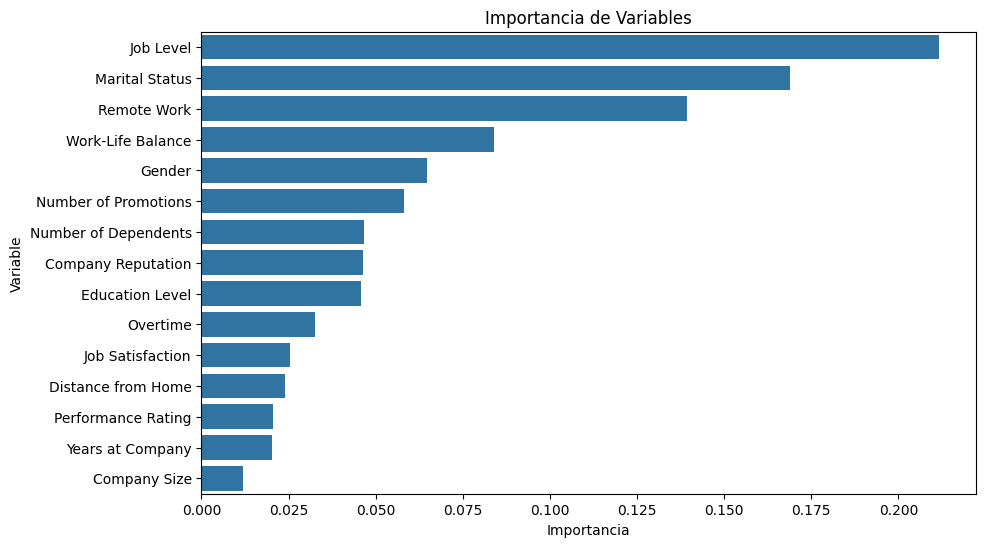

In [ ]:
# Interpretación de df_importancias
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancias)
plt.title('Importancia de Variables')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()



Podemos observar las 15 variables más importantes que influyen en la fuga, donde 3 de estas tienen una diferencia más marcada (Job Level, Marital Status y Remote Work)

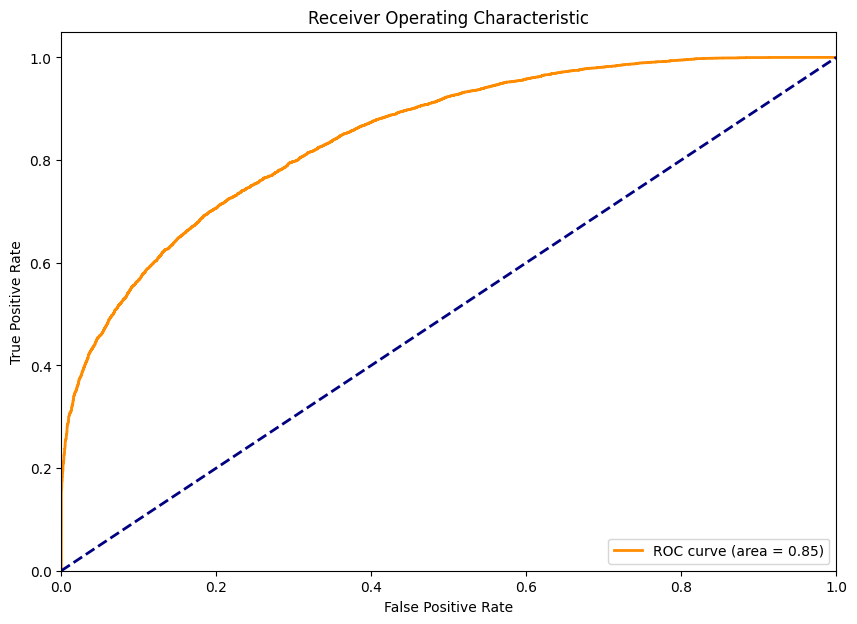

In [ ]:
# Plotting the ROC Curve
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgboost)
roc_auc = auc(fpr, tpr)

plt.figure(figsize =(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

El valor de 0.85 en la curva ROC significa que el modelo tiene un 85% de probabilidad de diferenciar correctamente entre un caso positivo y uno negativo, lo que lo hace confiable.

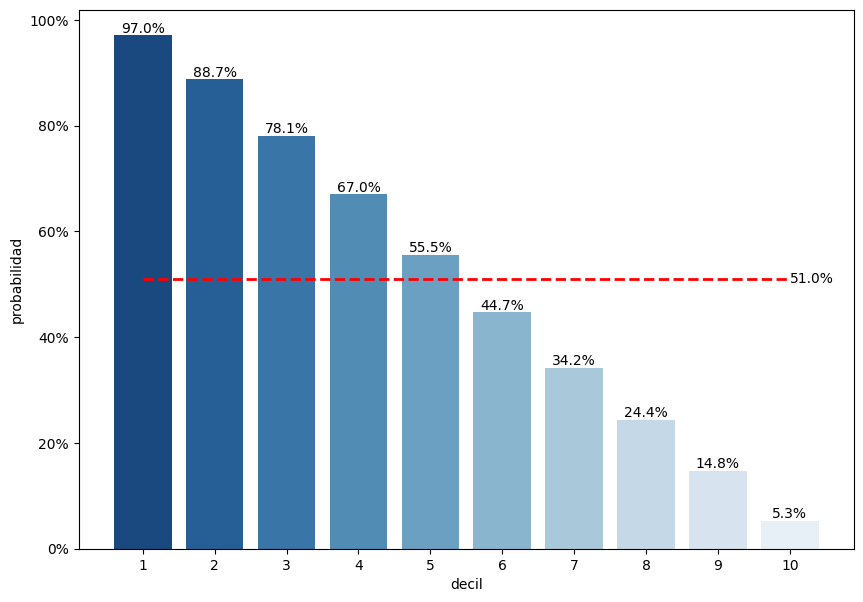

In [ ]:
n = 10

df_test = X_test.copy()
df_test['target'] = y_test
df_test['probabilidad'] = y_prob_xgboost

# Divides into deciles
df_test = df_test.sort_values("probabilidad", ascending = False)
df_test["decil"] = pd.qcut(df_test["probabilidad"], q = n, labels = list(range(n, 0, -1)))
# Plots the deciles
# sns.countplot(x = "decil", data = df_test, order = range(1, 11), palette = 'Blues_r')

# Avg probabilidad
avg_probabilidad = df_test[["probabilidad", "decil"]].groupby("decil").mean("probabilidad")

fig = plt.figure(figsize =(10, 7))

ax = plt.subplot()

fig.add_subplot(ax)

# Plots the decile x profit graph
ax = sns.barplot(x = "decil", y = "probabilidad", data = avg_probabilidad, order = range(1, n+1), palette = 'Blues_r')

ax.hlines(y=df_test['probabilidad'].mean(), xmin=0, xmax=n-1, colors='r', linestyles='--', lw=2)
plt.text(n-1, df_test['probabilidad'].mean(), f"{df_test['probabilidad'].mean()*100:.1f}%", ha ='left', va ='center')

for index, row in avg_probabilidad.iterrows():
    plt.text(index-1, row['probabilidad'], f"{row['probabilidad']*100:.1f}%", fontsize=10, color='black', ha='center', va='bottom')

# changing ylables ticks
y_value=['{:,.0%}'.format(x) for x in ax.get_yticks()]
ax.set_yticklabels(y_value)

plt.show()

El gráfico muestra cómo el modelo divide a todos los empleados en 10 grupos iguales (deciles)


*   Los 5 primeros grupos de ejecución, superan la efectividad promedio. Son empleados más críticos, más propensos a fugarse.
*   En grupo 1, el 97% de los empleados realmente se terminan yendo, o sea, el modelo acierta casi siempre en ese grupo.
*  Del grupo 6 al 10, no superan el promedio de efectividad, por ende es poco probable que los empleados de este grupo fuguen



## **6. Conclusiones** <a name="conclu"></a>



*   El modelo permite a las empresas identificar riesgos de rotación a tiempo, evitando costos de reclutamiento y capacitación. Al retener a empleados clave, optimiza recursos y reduce procesos administrativos. Además, facilita negociaciones con empleados en riesgo mediante estrategias como aumentos salariales y planes de desarrollo profesional para minimizar la rotación.
*   El modelo no solo evalúa a nuevos empleados, sino que también evalúa la satisfacción de los colaboradores antiguos y ajusta políticas de retención, como promociones o flexibilidad laboral. Integrado con People Analytics, mejora las predicciones y facilita acciones correctivas. Con el tiempo, se vuelve más preciso, permitiendo estrategias personalizadas que fortalecen la estabilidad del equipo, la confianza en la empresa y la competitividad del negocio.



## **7. Recomendaciones** <a name="reco"></a>



*   En base al modelo, podemos predecir si el talento nuevo, terminará renunciando si no estudiamos las variables más importantes, es por eso que es necesario, una evaluación previa con el talento
*   Con el modelo elaborado, se pueden hacer pequeños ajustes para estudiar a al talento actual y revisar con las variables más importantes (nivel de trabajo, estado civil o o brindarles trabajo remoto parcial) para evitar su fuga posteriormente
* En caso el talento sea posible fuga (pero realmente tiene buen perfil) una evaluación detallada según sus necesidades y si están directamente relacionadas con el modelo, poder negociar para que no renuncie y evitar costos y gastos administrativos que puedan afectar mas adelante la empresa



**RECOMENDACIONES PARA LAS CARACTERISTICAS MÁS PROPENSAS A LA FUGA**

**✅Job Level**

**Clarificar oportunidades de crecimiento:** Explicar las expectativas para ascender de Junior a Senior, y establecer un plan de desarrollo claro.

**Capacitación constante:** Ofrecer recursos para que el empleado mejore sus habilidades y pueda ascender.

**✅Marital status**

**Crear un canal de comunicación abierto:**
Fomentar una comunicación honesta y abierta para que los empleados puedan expresar cualquier preocupación relacionada con su vida personal y recibir apoyo sin temor a juicio o consecuencias negativas.


**✅Remote Work**

**Flexibilidad laboral:** Ofrecer opciones de horarios flexibles o trabajo remoto para aquellos empleados que puedan tener responsabilidades familiares o necesidades personales derivadas de su situación.

## **8. Recursos y Enlaces** <a name="recursos"></a>

**Recursos**
- [Dataset de kaggle](https://www.kaggle.com/datasets/alexhuitron/supermarket-sales/data)

**Enlaces**

- [Mi GitHub](https://github.com/mrojash97)
- [LinkedIn](https://www.linkedin.com/in/marlon-rojas)
- [Mi Web](https://marlonrojas.site)
.